# Clasificacion de Texto con BERT para Español (Transfer Learning)

Este notebook clasifica tickets de CRM usando la columna `descripcion` para predecir `areas_resolutora`.

**Estrategia: Transfer Learning (Feature Extraction)**
- Usamos BETO (BERT entrenado en español) como extractor de features.
- Congelamos TODAS las capas de BERT (no se actualizan sus pesos).
- Solo entrenamos la capa clasificadora que agregamos encima.
- Esto es mucho mas rapido y requiere menos datos que fine-tuning completo.

**Como detener y reanudar el entrenamiento:**
- El notebook guarda checkpoints automaticamente cada N pasos y al final de cada epoca.
- Para DETENER: interrumpi el kernel (boton stop o Kernel > Interrupt).
- Para REANUDAR: ejecuta la celda de entrenamiento de nuevo — detecta el ultimo checkpoint y continua desde ahi.
- Para USAR el modelo sin mas entrenamiento: salta directo a las celdas de prediccion/evaluacion.

## 0. Instalar dependencias
Ejecuta esto una sola vez. Despues reinicia el kernel.

In [1]:
# Instala todas las librerias necesarias desde requirements.txt
# !pip install -r requirements.txt -q

## 1. Imports y configuracion

In [2]:
# --- Librerias estandar de Python ---
import os  # Para interactuar con el sistema de archivos (rutas, directorios)
import warnings  # Para silenciar advertencias que no son criticas

# --- Librerias de datos ---
import pandas as pd  # Para leer y manipular datos tabulares (CSV, DataFrames)
import numpy as np  # Para operaciones numericas eficientes con arrays


In [3]:

# --- Librerias de Machine Learning ---
from sklearn.model_selection import train_test_split  # Para dividir datos en train/val/test
from sklearn.preprocessing import LabelEncoder  # Para convertir etiquetas texto a numeros
from sklearn.metrics import (  # Metricas para evaluar el modelo
    accuracy_score,  # Porcentaje de predicciones correctas
    precision_score,  # De las que predijo como X, cuantas realmente eran X
    recall_score,  # De las que realmente eran X, cuantas detecto
    f1_score,  # Media armonica entre precision y recall (balance)
    classification_report,  # Reporte completo por cada clase
    confusion_matrix,  # Tabla de predicciones vs realidad
    top_k_accuracy_score,  # Accuracy considerando las top-k predicciones
)


In [4]:

# --- Librerias de Deep Learning ---
import torch  # Framework principal de deep learning
from torch.utils.data import Dataset, DataLoader  # Para crear datasets y cargar datos en batches

# --- Librerias de Transformers (Hugging Face) ---
from transformers import (  # Ecosistema de modelos pre-entrenados
    BertTokenizer,  # Tokenizador: convierte texto a numeros que BERT entiende
    BertModel,  # El modelo BERT base (sin capa de clasificacion)
    get_linear_schedule_with_warmup,  # Learning rate scheduler con warmup
)

# --- Librerias de visualizacion ---
import matplotlib.pyplot as plt  # Para crear graficos y visualizaciones
import seaborn as sns  # Para graficos estadisticos mas bonitos (heatmaps, etc)

# --- Utilidades ---
from tqdm.notebook import tqdm  # Barra de progreso visual en notebooks

# Silenciamos warnings que no aportan informacion util
warnings.filterwarnings('ignore')

## 2. Verificar GPU
BERT es un modelo grande. Sin GPU, el entrenamiento puede tardar horas. Con GPU tarda minutos.

In [5]:
# Verificamos si hay una GPU disponible con soporte CUDA (NVIDIA)
# Si hay GPU, usamos 'cuda'; si no, usamos 'cpu' (mucho mas lento)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Mostramos que dispositivo se va a usar
print(f'Dispositivo seleccionado: {device}')

# Si hay GPU, mostramos informacion detallada
if torch.cuda.is_available():
    # Nombre de la GPU (ej: "NVIDIA GeForce RTX 3080")
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    # Memoria total de la GPU en GB
    print(f'Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    # Advertencia si no hay GPU — el entrenamiento sera muy lento
    print('ADVERTENCIA: No se detecto GPU. El entrenamiento sera mucho mas lento.')

Dispositivo seleccionado: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU
Memoria GPU: 8.1 GB


## 3. Cargar y preparar los datos

In [6]:
# Leemos el CSV. Solo cargamos las 2 columnas que necesitamos para ahorrar memoria
# - descripcion: el texto de entrada (lo que el modelo lee)
# - areas_resolutora: la etiqueta a predecir (la clase)
df= pd.read_csv('test.csv', usecols=['descripcion', 'areas_resolutora'])

# Mostramos cuantas filas tiene el dataset original
print(f'Filas totales en el dataset: {len(df)}')

# Mostramos las primeras 5 filas para entender la estructura
df.head()

Filas totales en el dataset: 88617


,descripcion,areas_resolutora
0,"Buenas tardes,\nSe contacta el cliente via red...",Sucursal Campo 9 (48)
1,Recibí un correo en fecha 07/07 informándome q...,Call Center
2,Deseo refinanciar la deuda de mi TC,"Banca Personas - Matriz, Oficiales Digitales"
3,"Buenas noches,\n\nSe contacta el cliente en re...","Banca Personas - Matriz, Oficiales Digitales"
4,"Buenos días, \n\nEn comunicación con la client...",Sucursal Santa Rita (26)


In [7]:
# Contamos cuantos valores nulos hay en cada columna
print('Valores nulos por columna:')
print(df.isnull().sum())  # .isnull() marca True donde hay NaN, .sum() los cuenta

# Eliminamos filas donde descripcion o areas_resolutora sean nulas
# No podemos entrenar si falta el texto de entrada o la etiqueta
df = df.dropna(subset=['descripcion', 'areas_resolutora'])

# Reseteamos el indice despues de eliminar filas (para que vaya 0,1,2,3...)
df = df.reset_index(drop=True)  # drop=True evita que el indice viejo se guarde como columna

# Mostramos cuantas filas quedaron despues de limpiar
print(f'\nFilas despues de limpiar nulos: {len(df)}')

# Mostramos cuantas clases unicas hay en areas_resolutora
print(f'Clases unicas (areas_resolutora): {df["areas_resolutora"].nunique()}')

Valores nulos por columna:
descripcion         65
areas_resolutora     2
dtype: int64

Filas despues de limpiar nulos: 88550
Clases unicas (areas_resolutora): 3290


In [8]:
df['areas_resolutora'] = df['areas_resolutora'].str.split(', ').str[-1]


In [9]:
df.nunique()

descripcion         84547
areas_resolutora      114
dtype: int64

In [10]:
def group_labels(label):                                                                                                                                                       
      if 'sucursal' in str(label).lower():                                                                                                                                               
          return 'sucursales'                                                                                                                                                    
      elif 'cac' in str(label).lower():                                                                                                                                                       
          return 'CAC'                                                                                                                                                         
      else:
          return label


In [11]:

df['labels']  = df['areas_resolutora'].apply(group_labels)

In [12]:
df

,descripcion,areas_resolutora,labels
0,"Buenas tardes,\nSe contacta el cliente via red...",Sucursal Campo 9 (48),sucursales
1,Recibí un correo en fecha 07/07 informándome q...,Call Center,Call Center
2,Deseo refinanciar la deuda de mi TC,Oficiales Digitales,Oficiales Digitales
3,"Buenas noches,\n\nSe contacta el cliente en re...",Oficiales Digitales,Oficiales Digitales
4,"Buenos días, \n\nEn comunicación con la client...",Sucursal Santa Rita (26),sucursales
...,...,...,...
88545,Como puedo saber donde se gasto de la tarjeta ...,Call Center,Call Center
88546,Si pueden verificar si ya esta habilitado mi t...,Call Center,Call Center
88547,Buenas ayer me hicieron un depósito de 10 mill...,Call Center,Call Center
88548,Préstamos,Call Center,Call Center


In [13]:
df.nunique()

descripcion         84547
areas_resolutora      114
labels                 58
dtype: int64

In [38]:
# Vemos la distribucion de clases: cuantos ejemplos tiene cada area_resolutora
# Esto es CRITICO porque si hay clases con muy pocos ejemplos, el modelo no aprendera bien
class_counts = df['labels'].value_counts()  # Cuenta ocurrencias y ordena de mayor a menor

# Mostramos las 20 clases mas frecuentes
print('classes:')
print(class_counts.head(60))

# Mostramos cuantas clases tienen menos de 10 ejemplos (estas seran problematicas)
print(f'\nClases con menos de 10 ejemplos: {(class_counts < 10).sum()}')

# Filtramos clases con muy pocos ejemplos (menos de 5)
# El modelo no puede aprender patrones de una clase con tan pocas muestras
MIN_SAMPLES = 100  # Minimo de ejemplos requeridos por clase

# Obtenemos las clases que SI tienen suficientes ejemplos
valid_classes = class_counts[class_counts >= MIN_SAMPLES].index  # .index nos da los nombres de las clases

# Filtramos el DataFrame para quedarnos solo con las clases validas
df_filter = df[df['labels'].isin(valid_classes)]  # .isin() chequea si el valor esta en la lista

# Reseteamos el indice de nuevo
df_filter = df_filter.reset_index(drop=True)

# Mostramos el resultado del filtrado
print(f'\nClases que se mantienen: {len(valid_classes)}')
print(f'Filas despues de filtrar clases minoritarias: {len(df)}')

classes:
labels
Call Center                       46893
sucursales                        21167
Oficiales Digitales                6576
Tarjetas                           2948
Fidelización y Retención           2411
Banca Personas - Matriz            1296
Canales Digitales                   931
ATC. Casa Matriz                    830
Tarjetas Logistica                  753
Seguridad Informatica               598
MonitoreoAtm                        561
Mesa de Ayuda                       462
Contimarket                         318
CAC                                 317
Operaciones Electrónicas            278
Calidad                             252
MonitoreoCCTV                       219
Sostenimiento App/Web               204
Contabilidad                        188
Operaciones ML                      156
Alianzas y Promociones              152
Pago de Salarios                    134
Administración de Créditos          111
Captaciones - Operaciones           102
Jefatura Operativa      

In [60]:
# Vemos la distribucion de clases: cuantos ejemplos tiene cada area_resolutora
# Esto es CRITICO porque si hay clases con muy pocos ejemplos, el modelo no aprendera bien
class_counts = df['labels'].value_counts()  # Cuenta ocurrencias y ordena de mayor a menor

# Mostramos las 20 clases mas frecuentes
print('classes:')
print(class_counts.head(60))

# Mostramos cuantas clases tienen menos de 10 ejemplos (estas seran problematicas)
print(f'\nClases con menos de 10 ejemplos: {(class_counts < 10).sum()}')

# Filtramos clases con muy pocos ejemplos
# El modelo no puede aprender patrones de una clase con tan pocas muestras
MIN_SAMPLES = 1000  # Minimo de ejemplos requeridos por clase

# Obtenemos las clases que SI tienen suficientes ejemplos
valid_classes = class_counts[class_counts >= MIN_SAMPLES].index  # .index nos da los nombres de las clases

# Filtramos el DataFrame para quedarnos solo con las clases validas
df_filter = df[df['labels'].isin(valid_classes)]  # .isin() chequea si el valor esta en la lista

# Reseteamos el indice de nuevo
df_filter = df_filter.reset_index(drop=True)

# Mostramos el resultado del filtrado
print(f'\nClases que se mantienen: {len(valid_classes)}')
print(f'Filas despues de filtrar clases minoritarias: {len(df_filter)}')
print(df_filter['labels'].unique())


classes:
labels
Call Center                       46893
sucursales                        21167
Oficiales Digitales                6576
Tarjetas                           2948
Fidelización y Retención           2411
Banca Personas - Matriz            1296
Canales Digitales                   931
ATC. Casa Matriz                    830
Tarjetas Logistica                  753
Seguridad Informatica               598
MonitoreoAtm                        561
Mesa de Ayuda                       462
Contimarket                         318
CAC                                 317
Operaciones Electrónicas            278
Calidad                             252
MonitoreoCCTV                       219
Sostenimiento App/Web               204
Contabilidad                        188
Operaciones ML                      156
Alianzas y Promociones              152
Pago de Salarios                    134
Administración de Créditos          111
Captaciones - Operaciones           102
Jefatura Operativa      

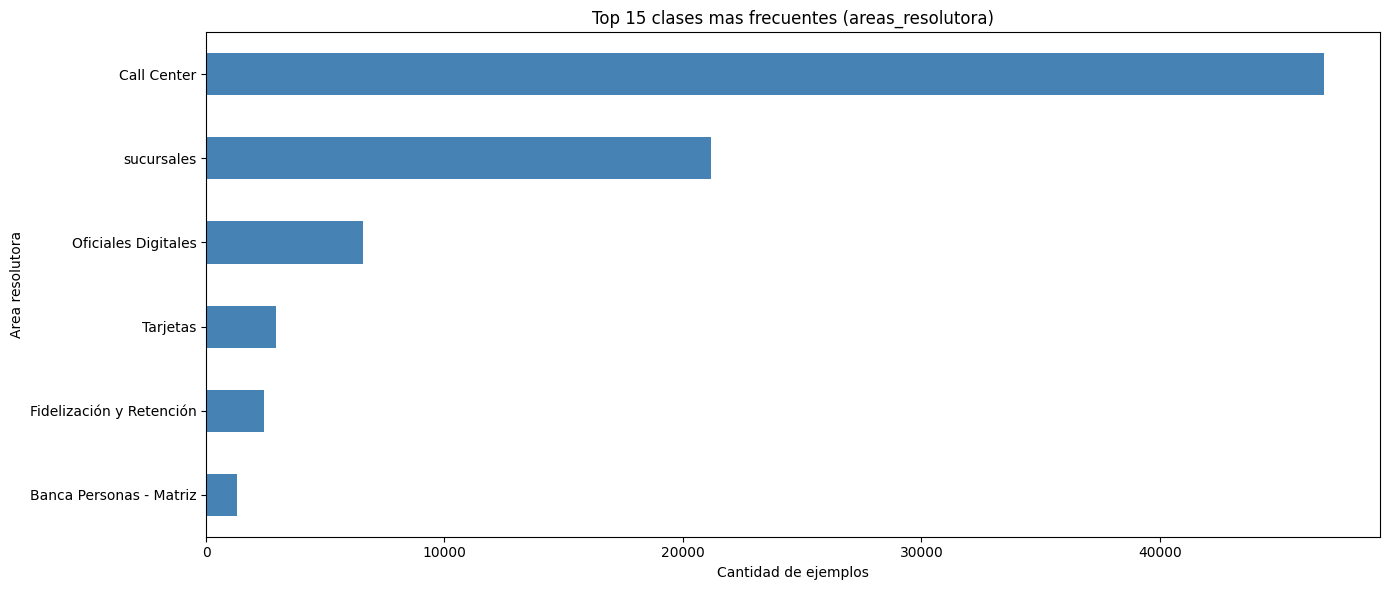

In [61]:
# Visualizamos la distribucion de las top 15 clases en un grafico de barras
plt.figure(figsize=(14, 6))  # Creamos una figura de 14x6 pulgadas

# Tomamos las 15 clases mas frecuentes y las graficamos
top_classes = df_filter['labels'].value_counts().head(15)  # Top 15 clases

# Creamos el grafico de barras horizontales
# barh = horizontal para que los nombres largos se lean bien
top_classes.plot(kind='barh', color='steelblue')

# Agregamos titulo y etiquetas a los ejes
plt.title('Top 15 clases mas frecuentes (areas_resolutora)')  # Titulo del grafico
plt.xlabel('Cantidad de ejemplos')  # Etiqueta eje X
plt.ylabel('Area resolutora')  # Etiqueta eje Y

# Invertimos el eje Y para que la clase mas frecuente este arriba
plt.gca().invert_yaxis()

# Ajustamos el layout para que no se corten las etiquetas
plt.tight_layout()

# Mostramos el grafico
plt.show()

## 4. Codificar etiquetas y dividir datos

In [62]:
# LabelEncoder convierte las etiquetas de texto a numeros
# Ejemplo: "Call Center" -> 0, "Sucursal" -> 1, "Banca Personas" -> 2, etc.
# Los modelos de deep learning necesitan numeros, no texto
label_encoder = LabelEncoder()

# .fit_transform() hace 2 cosas:
# 1. fit: aprende todas las clases unicas
# 2. transform: convierte cada etiqueta a su numero correspondiente
df_filter['label_encoder'] = label_encoder.fit_transform(df_filter['labels'])

# Guardamos el numero total de clases (lo necesitamos para la capa clasificadora)
num_classes = len(label_encoder.classes_)

# Mostramos el mapeo de clases a numeros
print(f'Numero total de clases: {num_classes}')
print('\nMapeo clase -> numero (primeras 10):')

# Iteramos por las clases para mostrar el mapeo
for i, cls in enumerate(label_encoder.classes_[:60]):  # Solo las primeras 10 para no saturar
    print(f'  {i}: {cls}')

Numero total de clases: 6

Mapeo clase -> numero (primeras 10):
  0: Banca Personas - Matriz
  1: Call Center
  2: Fidelización y Retención
  3: Oficiales Digitales
  4: Tarjetas
  5: sucursales


In [63]:
# Dividimos los datos en 3 conjuntos:
# - Train (70%): para que el modelo aprenda
# - Validation (15%): para monitorear durante el entrenamiento (detectar overfitting)
# - Test (15%): para la evaluacion final (NUNCA se usa durante el entrenamiento)

# Separamos los textos (X) de las etiquetas (y)
texts = df_filter['descripcion'].tolist()  # Lista de textos de entrada
labels = df_filter['label_encoder'].tolist()  # Lista de etiquetas numericas

# Primera division: 70% train, 30% temporal
# stratify=labels mantiene la misma proporcion de clases en cada conjunto
# random_state=42 hace que la division sea reproducible (siempre la misma)
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts,  # Los datos de entrada
    labels,  # Las etiquetas
    test_size=0.3,  # 30% para el conjunto temporal
    random_state=42,  # Semilla para reproducibilidad
    stratify=labels,  # Mantener proporcion de clases
)

# Segunda division: dividimos el 30% temporal en 15% validation + 15% test
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,  # Los datos temporales del paso anterior
    temp_labels,  # Las etiquetas temporales
    test_size=0.5,  # 50% del temporal = 15% del total
    random_state=42,  # Misma semilla para reproducibilidad
    stratify=temp_labels,  # Mantener proporcion de clases
)

# Mostramos cuantos ejemplos tiene cada conjunto
print(f'Ejemplos de entrenamiento (train): {len(train_texts)}')
print(f'Ejemplos de validacion (val): {len(val_texts)}')
print(f'Ejemplos de prueba (test): {len(test_texts)}')

Ejemplos de entrenamiento (train): 56903
Ejemplos de validacion (val): 12194
Ejemplos de prueba (test): 12194


## 5. Tokenizacion con BETO (BERT Español)

**BETO** es un modelo BERT pre-entrenado especificamente con textos en español.  
El tokenizador convierte cada texto en una secuencia de tokens (sub-palabras) que BERT puede procesar.

In [64]:
# Nombre del modelo pre-entrenado en español
# "dccuchile/bert-base-spanish-wwm-cased" es BETO, entrenado por la U. de Chile
# - spanish: entrenado con textos en español
# - wwm: Whole Word Masking (mejor tecnica de pre-entrenamiento)
# - cased: distingue mayusculas de minusculas
MODEL_NAME = 'dccuchile/bert-base-spanish-wwm-cased'

# Cargamos el tokenizador pre-entrenado
# El tokenizador sabe como dividir texto en español en sub-palabras
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

# Ejemplo de como funciona el tokenizador
ejemplo = 'El cliente solicita el bloqueo de su tarjeta de credito'

# Tokenizamos el ejemplo para ver como lo procesa
tokens = tokenizer.tokenize(ejemplo)  # Divide en sub-palabras

# Mostramos el texto original y sus tokens
print(f'Texto original: {ejemplo}')
print(f'Tokens: {tokens}')  # Los tokens que BERT ve
print(f'Cantidad de tokens: {len(tokens)}')  # Cuantos tokens genero

Texto original: El cliente solicita el bloqueo de su tarjeta de credito
Tokens: ['El', 'cliente', 'solicita', 'el', 'bloqueo', 'de', 'su', 'tarjeta', 'de', 'credi', '##to']
Cantidad de tokens: 11


In [65]:
# Definimos la longitud maxima de tokens por texto
# BERT tiene un limite de 512 tokens. Usamos 128 como compromiso:
# - Cubre la mayoria de textos (mediana ~82 tokens)
# - Usa menos memoria y es mas rapido que 256
# - Textos mas largos se TRUNCAN (se cortan al maximo)
# - Textos mas cortos se PADDEAN (se rellenan con ceros)
MAX_LENGTH = 128

# Veamos la distribucion de longitudes de tokens en el dataset
# Tomamos una muestra de 1000 textos para no tardar mucho
sample_lengths = []  # Lista para guardar las longitudes

# Iteramos por 1000 textos aleatorios del conjunto de entrenamiento
for text in train_texts[:1000]:
    # Tokenizamos cada texto y contamos cuantos tokens tiene
    tokens = tokenizer.tokenize(str(text))  # str() por si hay valores raros
    sample_lengths.append(len(tokens))  # Guardamos la longitud

# Mostramos estadisticas de las longitudes
print(f'Longitud promedio de tokens: {np.mean(sample_lengths):.0f}')
print(f'Longitud mediana de tokens: {np.median(sample_lengths):.0f}')
print(f'Longitud maxima de tokens: {np.max(sample_lengths)}')
print(f'Percentil 95: {np.percentile(sample_lengths, 95):.0f}')
print(f'Textos que se truncaran (>{MAX_LENGTH} tokens): {sum(1 for l in sample_lengths if l > MAX_LENGTH)} de 1000')

Token indices sequence length is longer than the specified maximum sequence length for this model (662 > 512). Running this sequence through the model will result in indexing errors


Longitud promedio de tokens: 81
Longitud mediana de tokens: 76
Longitud maxima de tokens: 662
Percentil 95: 195
Textos que se truncaran (>128 tokens): 204 de 1000


## 6. Crear Dataset de PyTorch

PyTorch necesita un objeto `Dataset` que sepa como:
1. Tomar un texto y su etiqueta
2. Tokenizarlo (convertirlo a numeros)
3. Devolver los tensores que BERT necesita

In [66]:
# Definimos una clase personalizada que hereda de torch.utils.data.Dataset
class TicketDataset(Dataset):
    
    def __init__(self, texts, labels, tokenizer, max_length):
        """Inicializa el dataset pre-tokenizando TODOS los textos de una vez."""
        self.labels = labels  # Lista de etiquetas numericas
        
        # Pre-tokenizamos todos los textos de una sola vez
        # Esto es MUCHO mas rapido que tokenizar en __getitem__ (que se ejecuta cada epoch)
        print(f'Pre-tokenizando {len(texts)} textos...')
        self.encodings = tokenizer(
            [str(t) for t in texts],  # Lista de todos los textos
            add_special_tokens=True,  # Agrega [CLS] al inicio y [SEP] al final
            max_length=max_length,  # Largo maximo en tokens
            padding='max_length',  # Rellena con ceros hasta max_length
            truncation=True,  # Corta textos que excedan max_length
            return_attention_mask=True,  # Mascara: 1 donde hay token real, 0 donde hay padding
            return_tensors='pt',  # Devuelve tensores de PyTorch
        )
        print('Tokenizacion completa!')
    
    def __len__(self):
        """Devuelve cuantos ejemplos tiene el dataset."""
        return len(self.labels)
    
    def __getitem__(self, idx):
        """Devuelve un ejemplo ya tokenizado dado su indice."""
        # Solo busca los tensores pre-calculados — sin tokenizar nada
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [67]:
# Creamos los 3 datasets (train, validation, test)
# Cada uno recibe sus textos, etiquetas, el tokenizador y la longitud maxima

# Dataset de entrenamiento: el modelo aprende de estos datos
train_dataset = TicketDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)

# Dataset de validacion: para monitorear el rendimiento durante el entrenamiento
val_dataset = TicketDataset(val_texts, val_labels, tokenizer, MAX_LENGTH)

# Dataset de prueba: evaluacion final despues del entrenamiento
test_dataset = TicketDataset(test_texts, test_labels, tokenizer, MAX_LENGTH)

# Definimos el tamano de batch
# Batch = cuantos ejemplos procesa el modelo a la vez
# - Mas grande = mas rapido pero usa mas memoria GPU
# - Si te da error de memoria, reduce este numero (a 8 o 4)
BATCH_SIZE = 16

# Creamos los DataLoaders: iteradores que entregan datos en batches
# shuffle=True mezcla los datos cada epoca (solo en train, para que no memorice el orden)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# En validacion y test NO mezclamos (no es necesario y es mas reproducible)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Verificamos que todo funcione tomando un batch de ejemplo
sample_batch = next(iter(train_loader))  # Tomamos el primer batch

# Mostramos las dimensiones de cada tensor en el batch
print(f'Shape input_ids: {sample_batch["input_ids"].shape}')  # [batch_size, max_length]
print(f'Shape attention_mask: {sample_batch["attention_mask"].shape}')  # [batch_size, max_length]
print(f'Shape labels: {sample_batch["label"].shape}')  # [batch_size]

Pre-tokenizando 56903 textos...
Tokenizacion completa!
Pre-tokenizando 12194 textos...
Tokenizacion completa!
Pre-tokenizando 12194 textos...
Tokenizacion completa!
Shape input_ids: torch.Size([16, 128])
Shape attention_mask: torch.Size([16, 128])
Shape labels: torch.Size([16])


## 7. Definir el modelo (Transfer Learning - Fine-Tuning Parcial)

**Transfer Learning** significa usar un modelo ya entrenado en una tarea grande y adaptarlo a nuestra tarea.

**Fine-Tuning Parcial** (lo que hacemos aqui):
- Congelamos las primeras 10 capas de BERT (features generales del idioma).
- Descongelamos las ultimas 2 capas (layers 10-11) + pooler para que se adapten a nuestros datos.
- Entrenamos una capa clasificadora simple encima.

**Ventajas vs Feature Extraction (todo congelado):**
- BERT adapta sus representaciones a nuestro dominio (tickets CRM).
- Mejor accuracy con el mismo dataset.

In [68]:
# Definimos nuestro modelo de clasificacion basado en BERT
class BERTClassifier(torch.nn.Module):
    
    def __init__(self, model_name, num_classes, dropout_rate=0.1):
        """Inicializa el clasificador con BERT parcialmente descongelado + capa clasificadora."""
        super(BERTClassifier, self).__init__()
        
        # Cargamos el modelo BERT pre-entrenado (BETO)
        self.bert = BertModel.from_pretrained(model_name)
        
        # === TRANSFER LEARNING: CONGELAR BERT PARCIALMENTE ===
        # Congelamos todas las capas primero
        for param in self.bert.parameters():
            param.requires_grad = False
        
        # Descongelamos las ultimas 2 capas del encoder + pooler
        # Esto permite que BERT adapte sus representaciones a nuestros datos
        # Las capas inferiores capturan features generales (sintaxis, etc.)
        # Las capas superiores capturan features mas especificas (semantica del dominio)
        for name, param in self.bert.named_parameters():
            if 'encoder.layer.11' in name or 'encoder.layer.10' in name or 'pooler' in name:
                param.requires_grad = True
        
        # Obtenemos la dimension del vector de salida de BERT (768 para bert-base)
        hidden_size = self.bert.config.hidden_size  # 768
        
        # === CAPA CLASIFICADORA SIMPLE ===
        # Con fine-tuning de BERT, una capa simple funciona mejor
        # BERT ya aprende representaciones adaptadas a nuestra tarea
        self.classifier = torch.nn.Sequential(
            torch.nn.Dropout(dropout_rate),
            torch.nn.Linear(hidden_size, num_classes),
        )
    
    def forward(self, input_ids, attention_mask):
        """Define como fluyen los datos a traves del modelo."""
        # Pasamos el texto tokenizado por BERT
        # Ya NO usamos torch.no_grad() porque las ultimas capas SI se entrenan
        bert_output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        
        # Tomamos el pooler_output: vector resumen del texto completo
        pooled_output = bert_output.pooler_output
        
        # Pasamos el vector por nuestra capa clasificadora
        logits = self.classifier(pooled_output)
        
        # Devolvemos los logits (valores sin normalizar)
        # CrossEntropyLoss aplica softmax internamente
        return logits

In [69]:
# Creamos una instancia del modelo
model = BERTClassifier(
    model_name=MODEL_NAME,  # BETO (BERT español)
    num_classes=num_classes,  # Cantidad de areas_resolutora unicas
    dropout_rate=0.1,  # 10% de dropout (suficiente con fine-tuning)
)

# Movemos el modelo a la GPU (o CPU si no hay GPU)
model = model.to(device)

# Mostramos cuantos parametros tiene el modelo y cuantos se entrenan
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f'Parametros totales: {total_params:,}')
print(f'Parametros congelados (BERT capas 0-9): {frozen_params:,}')
print(f'Parametros entrenables (capas 10-11 + pooler + clasificador): {trainable_params:,}')
print(f'Porcentaje que se entrena: {trainable_params/total_params*100:.2f}%')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on 

Parametros totales: 109,855,494
Parametros congelados (BERT capas 0-9): 95,084,544
Parametros entrenables (capas 10-11 + pooler + clasificador): 14,770,950
Porcentaje que se entrena: 13.45%


## 8. Configurar entrenamiento

In [70]:
# === HIPERPARAMETROS ===

# Numero de epocas (pasadas completas sobre los datos de entrenamiento)
# Mas epocas = mas oportunidades de aprender, pero riesgo de overfitting
NUM_EPOCHS = 5

# Learning rate: que tan grandes son los "pasos" de aprendizaje
# - Muy alto: el modelo no converge (salta por todos lados)
# - Muy bajo: el modelo aprende muy lento
# 2e-5 es el rango recomendado para fine-tuning de modelos BERT
LEARNING_RATE = 2e-5

# Directorio donde se guardan los checkpoints (para reanudar entrenamiento)
CHECKPOINT_DIR = 'checkpoints'

# Creamos el directorio si no existe
# Aqui se guardaran:
# - last_checkpoint.pt: ultimo estado del entrenamiento (para reanudar)
# - best_model.pt: mejor modelo encontrado (para predicciones finales)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)  # exist_ok=True evita error si ya existe

In [71]:
# === FUNCION DE PERDIDA CON CLASS WEIGHTS ===
# Calculamos pesos inversamente proporcionales a la frecuencia de cada clase
# Clases con pocos ejemplos reciben mas peso -> el modelo les presta mas atencion
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',  # Calcula pesos automaticamente: n_samples / (n_classes * count_per_class)
    classes=np.unique(train_labels),  # Todas las clases unicas
    y=train_labels,  # Las etiquetas de entrenamiento
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print(f'Class weights (min: {class_weights.min():.2f}, max: {class_weights.max():.2f})')

# CrossEntropyLoss con pesos: penaliza mas los errores en clases minoritarias
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

# === OPTIMIZADOR ===
# AdamW: variante de Adam con weight decay (regularizacion L2 corregida)
# Solo optimizamos los parametros que requieren gradientes (el clasificador)
# filter(lambda p: p.requires_grad, ...) filtra solo los parametros entrenables
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),  # Solo parametros no congelados
    lr=LEARNING_RATE,  # Tasa de aprendizaje
    weight_decay=0.01,  # Regularizacion para prevenir overfitting
)

# === SCHEDULER ===
# Ajusta el learning rate durante el entrenamiento:
# 1. Warmup: sube gradualmente de 0 al LR maximo (primeros 10% de pasos)
# 2. Decay: baja linealmente hasta 0 (resto del entrenamiento)
# Esto estabiliza el entrenamiento al inicio y permite ajuste fino al final

# Calculamos el total de pasos de entrenamiento
total_steps = len(train_loader) * NUM_EPOCHS  # batches_por_epoca * epocas

# Creamos el scheduler con 10% de warmup
scheduler = get_linear_schedule_with_warmup(
    optimizer,  # El optimizador que va a controlar
    num_warmup_steps=int(total_steps * 0.1),  # 10% de pasos para warmup
    num_training_steps=total_steps,  # Total de pasos
)

# Mostramos la configuracion
print(f'Total de pasos de entrenamiento: {total_steps:,}')
print(f'Pasos de warmup: {int(total_steps * 0.1):,}')

Class weights (min: 0.29, max: 10.46)
Total de pasos de entrenamiento: 17,785
Pasos de warmup: 1,778


## 9. Funciones auxiliares: guardar/cargar checkpoints

### Como detener y reanudar el entrenamiento:

1. **Para DETENER**: Interrumpi el kernel (boton stop / Kernel > Interrupt).  
   El ultimo checkpoint se guardo automaticamente.

2. **Para REANUDAR**: Ejecuta la celda de entrenamiento de nuevo.  
   Detecta el ultimo checkpoint y continua desde esa epoca/paso.

3. **Para USAR el modelo sin mas entrenamiento**:  
   Salta directo a la Seccion 11 (Evaluacion) o 12 (Prediccion).
   Carga el mejor checkpoint con `load_checkpoint()`.

In [72]:
def save_checkpoint(model, optimizer, scheduler, epoch, step, val_loss, val_acc, path):
    """Guarda el estado completo del entrenamiento en un archivo."""
    # Creamos un diccionario con TODO lo necesario para reanudar
    checkpoint = {
        'epoch': epoch,  # En que epoca estamos
        'step': step,  # En que paso global estamos
        'model_state_dict': model.state_dict(),  # Pesos del modelo
        'optimizer_state_dict': optimizer.state_dict(),  # Estado del optimizador (momentums, etc)
        'scheduler_state_dict': scheduler.state_dict(),  # Estado del scheduler (LR actual)
        'val_loss': val_loss,  # Loss de validacion (para comparar modelos)
        'val_acc': val_acc,  # Accuracy de validacion
    }
    # torch.save serializa el diccionario a un archivo binario
    torch.save(checkpoint, path)


def load_checkpoint(model, optimizer=None, scheduler=None, path=None):
    """Carga un checkpoint previamente guardado."""
    # Si no se especifica un path, buscamos el ultimo checkpoint
    if path is None:
        # Buscamos el archivo 'best_model.pt' que es el mejor modelo guardado
        path = os.path.join(CHECKPOINT_DIR, 'best_model.pt')
    
    # Verificamos que el archivo exista
    if not os.path.exists(path):
        print(f'No se encontro checkpoint en: {path}')
        # Devolvemos 0 para epoca y paso (empezar desde cero)
        return 0, 0
    
    # Cargamos el checkpoint
    # map_location=device asegura que se cargue en el dispositivo correcto (GPU/CPU)
    checkpoint = torch.load(path, map_location=device)
    
    # Restauramos los pesos del modelo
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Restauramos el optimizador si se proporciono (necesario para reanudar entrenamiento)
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    # Restauramos el scheduler si se proporciono
    if scheduler is not None:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    
    # Mostramos informacion del checkpoint cargado
    print(f'Checkpoint cargado: epoca {checkpoint["epoch"]}, paso {checkpoint["step"]}')
    print(f'Val Loss: {checkpoint["val_loss"]:.4f}, Val Acc: {checkpoint["val_acc"]:.4f}')
    
    # Devolvemos la epoca y paso para continuar desde ahi
    return checkpoint['epoch'], checkpoint['step']

## 10. Entrenamiento

**IMPORTANTE:** Si interrumpis el kernel, podes reanudar ejecutando esta celda de nuevo.  
El codigo detecta el ultimo checkpoint y continua desde ahi.

In [73]:
# === INTENTAR REANUDAR DESDE UN CHECKPOINT ===
# Si ya existe un checkpoint, lo cargamos y continuamos
resume_path = os.path.join(CHECKPOINT_DIR, 'last_checkpoint.pt')  # Ruta del ultimo checkpoint

# Intentamos cargar el checkpoint
start_epoch, global_step = load_checkpoint(model, optimizer, scheduler, resume_path)

# Listas para guardar el historial de metricas (para graficar despues)
train_losses = []  # Loss de entrenamiento por epoca
val_losses = []  # Loss de validacion por epoca
val_accuracies = []  # Accuracy de validacion por epoca

# Mejor loss de validacion encontrado hasta ahora (para guardar el mejor modelo)
best_val_loss = float('inf')  # Empezamos con infinito para que cualquier loss sea mejor

# Mostramos informacion del entrenamiento
print(f'\nIniciando entrenamiento desde epoca {start_epoch}...')
print(f'Epocas: {start_epoch} -> {NUM_EPOCHS}')
print(f'Batches por epoca: {len(train_loader)}')
print(f'Dispositivo: {device}')
print('=' * 60)

No se encontro checkpoint en: checkpoints/last_checkpoint.pt

Iniciando entrenamiento desde epoca 0...
Epocas: 0 -> 5
Batches por epoca: 3557
Dispositivo: cuda


In [ ]:
# === LOOP DE ENTRENAMIENTO ===
# Iteramos por cada epoca (una epoca = una pasada completa por los datos de train)
for epoch in range(start_epoch, NUM_EPOCHS):
    
    # --- FASE DE ENTRENAMIENTO ---
    # model.train() activa el modo entrenamiento:
    # - Dropout esta ACTIVO (apaga neuronas aleatoriamente)
    # - BatchNorm usa estadisticas del batch actual
    model.train()
    
    # Variable para acumular la loss total de esta epoca
    total_train_loss = 0
    
    # Contadores para calcular accuracy de entrenamiento
    train_correct = 0  # Predicciones correctas
    train_total = 0  # Total de predicciones
    
    # Creamos una barra de progreso para esta epoca
    train_bar = tqdm(train_loader, desc=f'Epoca {epoch+1}/{NUM_EPOCHS} [Train]')
    
    # Iteramos por cada batch del DataLoader
    for batch_idx, batch in enumerate(train_bar):
        
        # Movemos los datos del batch a la GPU
        # .to(device) copia el tensor a la memoria de la GPU
        input_ids = batch['input_ids'].to(device)  # Tokens: [batch_size, max_length]
        attention_mask = batch['attention_mask'].to(device)  # Mascara: [batch_size, max_length]
        labels = batch['label'].to(device)  # Etiquetas: [batch_size]
        
        # Paso 1: Limpiar los gradientes del paso anterior
        # Si no los limpiamos, se acumulan (esto es un bug comun)
        optimizer.zero_grad()
        
        # Paso 2: Forward pass — pasar datos por el modelo
        # El modelo devuelve logits (valores sin normalizar para cada clase)
        logits = model(input_ids, attention_mask)  # [batch_size, num_classes]
        
        # Paso 3: Calcular la loss (que tan mal predijo el modelo)
        loss = criterion(logits, labels)  # Compara predicciones vs etiquetas reales
        
        # Paso 4: Backward pass — calcular gradientes
        # PyTorch calcula automaticamente la derivada de la loss respecto a cada parametro
        loss.backward()
        
        # Paso 5: Gradient clipping — limitar la magnitud de los gradientes
        # Previene "exploding gradients" (gradientes enormes que desestabilizan el entrenamiento)
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),  # Parametros del modelo
            max_norm=1.0,  # Los gradientes no pueden tener norma mayor a 1.0
        )
        
        # Paso 6: Actualizar pesos — el optimizador ajusta los parametros
        # Solo actualiza los parametros con requires_grad=True (el clasificador)
        optimizer.step()
        
        # Paso 7: Actualizar el learning rate segun el scheduler
        scheduler.step()
        
        # Acumulamos la loss para el promedio de la epoca
        total_train_loss += loss.item()  # .item() convierte tensor a numero Python
        
        # Calculamos predicciones para el accuracy
        # torch.max devuelve (valor_maximo, indice_del_maximo)
        # El indice del maximo es la clase predicha
        _, predicted = torch.max(logits, dim=1)  # dim=1 = a lo largo de las clases
        
        # Contamos predicciones correctas y totales
        train_total += labels.size(0)  # Tamano del batch
        train_correct += (predicted == labels).sum().item()  # Cuantas coinciden
        
        # Actualizamos la barra de progreso con loss y accuracy actuales
        train_bar.set_postfix({
            'loss': f'{loss.item():.4f}',  # Loss del batch actual
            'acc': f'{train_correct/train_total:.4f}',  # Accuracy acumulada
            'lr': f'{scheduler.get_last_lr()[0]:.2e}',  # Learning rate actual
        })
        
        # Incrementamos el contador global de pasos
        global_step += 1
        
        # Guardamos checkpoint periodicamente (cada N pasos)
        if global_step % 500 == 0:
            save_checkpoint(
                model, optimizer, scheduler,
                epoch, global_step, 0, 0,  # Loss/acc temporales (se actualiza al final de epoca)
                os.path.join(CHECKPOINT_DIR, 'last_checkpoint.pt'),  # Ruta del checkpoint
            )
    
    # Calculamos la loss promedio de la epoca completa
    avg_train_loss = total_train_loss / len(train_loader)
    
    # Calculamos el accuracy de entrenamiento de la epoca
    train_acc = train_correct / train_total
    
    # --- FASE DE VALIDACION ---
    # model.eval() activa el modo evaluacion:
    # - Dropout esta DESACTIVADO (usamos todas las neuronas)
    # - BatchNorm usa estadisticas acumuladas (no del batch actual)
    model.eval()
    
    # Variables para acumular metricas de validacion
    total_val_loss = 0  # Loss acumulada
    val_correct = 0  # Predicciones correctas
    val_total = 0  # Total de predicciones
    
    # torch.no_grad() desactiva el calculo de gradientes
    # En validacion no necesitamos gradientes — ahorra memoria y es mas rapido
    with torch.no_grad():
        # Iteramos por los batches de validacion
        for batch in tqdm(val_loader, desc=f'Epoca {epoch+1}/{NUM_EPOCHS} [Val]'):
            # Movemos datos a GPU
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            # Forward pass (sin backward porque es validacion)
            logits = model(input_ids, attention_mask)
            
            # Calculamos loss de validacion
            loss = criterion(logits, labels)
            total_val_loss += loss.item()
            
            # Calculamos predicciones y accuracy
            _, predicted = torch.max(logits, dim=1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    # Calculamos promedios de la epoca
    avg_val_loss = total_val_loss / len(val_loader)  # Loss promedio de validacion
    val_acc = val_correct / val_total  # Accuracy de validacion
    
    # Guardamos las metricas en las listas (para graficar despues)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)
    
    # Mostramos un resumen de la epoca
    print(f'\nEpoca {epoch+1}/{NUM_EPOCHS}')
    print(f'  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}')
    print(f'  Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.4f}')
    
    # Guardamos el checkpoint de la epoca
    save_checkpoint(
        model, optimizer, scheduler,
        epoch + 1, global_step,  # epoch+1 porque ya completamos esta epoca
        avg_val_loss, val_acc,
        os.path.join(CHECKPOINT_DIR, 'last_checkpoint.pt'),
    )
    
    # Si esta es la mejor loss de validacion, guardamos como "best_model"
    # Solo guardamos el modelo cuando MEJORA — esto es "early stopping manual"
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss  # Actualizamos el mejor valor
        # Guardamos el mejor modelo en un archivo separado
        save_checkpoint(
            model, optimizer, scheduler,
            epoch + 1, global_step,
            avg_val_loss, val_acc,
            os.path.join(CHECKPOINT_DIR, 'best_model.pt'),
        )
        print(f'  >>> Nuevo mejor modelo guardado! (Val Loss: {avg_val_loss:.4f})')
    
    print('=' * 60)

# Mensaje final
print('\nEntrenamiento completado!')
print(f'Mejor Val Loss: {best_val_loss:.4f}')

Epoca 1/5 [Train]:   0%|          | 0/3557 [00:00<?, ?it/s]

Epoca 1/5 [Val]:   0%|          | 0/763 [00:00<?, ?it/s]


Epoca 1/5
  Train Loss: 1.1689 | Train Acc: 0.6530
  Val Loss:   1.0150 | Val Acc:   0.7452
  >>> Nuevo mejor modelo guardado! (Val Loss: 1.0150)


Epoca 2/5 [Train]:   0%|          | 0/3557 [00:00<?, ?it/s]

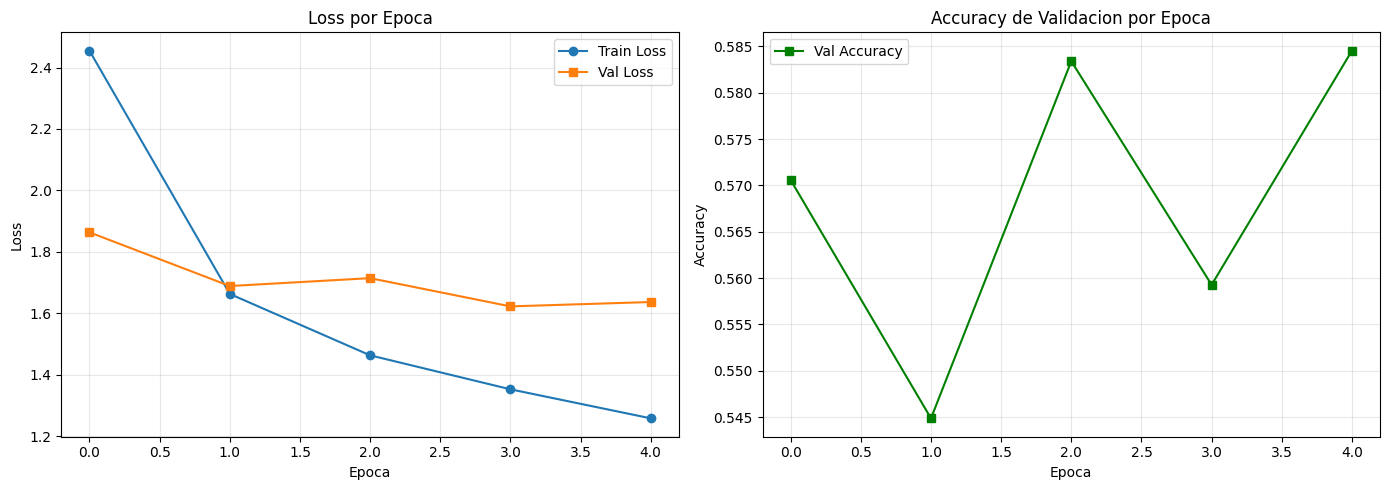

In [30]:
# === GRAFICAR CURVAS DE ENTRENAMIENTO ===
# Estas curvas nos dicen si el modelo esta aprendiendo bien o tiene problemas

# Creamos una figura con 2 subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 1 fila, 2 columnas

# --- Subplot 1: Loss ---
# Si train_loss baja pero val_loss sube = OVERFITTING
# Si ambas bajan juntas = el modelo generaliza bien
axes[0].plot(train_losses, label='Train Loss', marker='o')  # Loss de entrenamiento
axes[0].plot(val_losses, label='Val Loss', marker='s')  # Loss de validacion
axes[0].set_title('Loss por Epoca')  # Titulo
axes[0].set_xlabel('Epoca')  # Eje X
axes[0].set_ylabel('Loss')  # Eje Y
axes[0].legend()  # Leyenda
axes[0].grid(True, alpha=0.3)  # Grilla suave

# --- Subplot 2: Accuracy de validacion ---
# Deberia subir con cada epoca (si el modelo mejora)
axes[1].plot(val_accuracies, label='Val Accuracy', marker='s', color='green')
axes[1].set_title('Accuracy de Validacion por Epoca')  # Titulo
axes[1].set_xlabel('Epoca')  # Eje X
axes[1].set_ylabel('Accuracy')  # Eje Y
axes[1].legend()  # Leyenda
axes[1].grid(True, alpha=0.3)  # Grilla suave

# Ajustamos el layout y mostramos
plt.tight_layout()
plt.show()

## 11. Evaluacion completa en el conjunto de test

Cargamos el **mejor modelo** (el que tuvo menor val_loss) y lo evaluamos en datos que **nunca vio**.

In [31]:
# Cargamos el mejor modelo guardado durante el entrenamiento
# Solo pasamos el modelo (no optimizer/scheduler porque no vamos a entrenar)
load_checkpoint(model, path=os.path.join(CHECKPOINT_DIR, 'best_model.pt'))

# Ponemos el modelo en modo evaluacion
model.eval()

# Listas para guardar todas las predicciones y etiquetas reales
all_predictions = []  # Lo que el modelo predijo
all_labels = []  # La respuesta correcta
all_probabilities = []  # Las probabilidades de cada clase

# Evaluamos sin calcular gradientes (mas rapido, menos memoria)
with torch.no_grad():
    # Iteramos por todos los batches del test set
    for batch in tqdm(test_loader, desc='Evaluando en test set'):
        # Movemos datos a GPU
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        # Forward pass
        logits = model(input_ids, attention_mask)  # [batch_size, num_classes]
        
        # Convertimos logits a probabilidades con softmax
        # Softmax normaliza los logits para que sumen 1 (probabilidades)
        probabilities = torch.softmax(logits, dim=1)  # [batch_size, num_classes]
        
        # Obtenemos la clase predicha (la de mayor probabilidad)
        _, predicted = torch.max(logits, dim=1)
        
        # Guardamos los resultados (los movemos a CPU y convertimos a numpy)
        all_predictions.extend(predicted.cpu().numpy())  # Predicciones
        all_labels.extend(labels.cpu().numpy())  # Etiquetas reales
        all_probabilities.extend(probabilities.cpu().numpy())  # Probabilidades

# Convertimos a arrays de numpy para calcular metricas
all_predictions = np.array(all_predictions)  # Array de predicciones
all_labels = np.array(all_labels)  # Array de etiquetas reales
all_probabilities = np.array(all_probabilities)  # Matriz de probabilidades

print(f'Total de predicciones: {len(all_predictions)}')

Checkpoint cargado: epoca 4, paso 15476
Val Loss: 1.6223, Val Acc: 0.5593


Evaluando en test set:   0%|          | 0/829 [00:00<?, ?it/s]

Total de predicciones: 13263


## 12. Metricas detalladas

### Que es cada metrica y por que importa:

| Metrica | Que mide | Por que importa |
|---------|----------|------------------|
| **Accuracy** | % de predicciones correctas | Vision general, pero engañosa si las clases estan desbalanceadas |
| **Precision** | De las que predijo como X, cuantas realmente eran X | Importante cuando los falsos positivos son costosos |
| **Recall** | De las que realmente eran X, cuantas detecto | Importante cuando los falsos negativos son costosos |
| **F1-Score** | Media armonica de Precision y Recall | Mejor metrica general para datos desbalanceados |
| **Top-K Accuracy** | Si la respuesta correcta esta en las top-K predicciones | Util cuando el modelo no esta seguro pero sugiere bien |

In [32]:
# === ACCURACY (Exactitud) ===
# Formula: predicciones_correctas / total_de_predicciones
# Ejemplo: si de 100 tickets, 78 los clasifico bien -> accuracy = 0.78 (78%)
# LIMITACION: si el 90% de los tickets son "Call Center", un modelo que siempre
# diga "Call Center" tendria 90% de accuracy pero seria inutil
accuracy = accuracy_score(all_labels, all_predictions)

# === PRECISION (Macro) ===
# Formula por clase: verdaderos_positivos / (verdaderos_positivos + falsos_positivos)
# "De todos los tickets que dijo que eran Call Center, cuantos REALMENTE eran Call Center?"
# macro = se calcula por cada clase y se promedia (trata todas las clases como igualmente importantes)
# Es importante cuando los FALSOS POSITIVOS son costosos
# Ejemplo: si asigna un ticket a un area incorrecta, ese area pierde tiempo revisandolo
precision = precision_score(all_labels, all_predictions, average='macro', zero_division=0)

# === RECALL (Sensibilidad/Cobertura) (Macro) ===
# Formula por clase: verdaderos_positivos / (verdaderos_positivos + falsos_negativos)
# "De todos los tickets que REALMENTE eran Call Center, cuantos detecto correctamente?"
# Es importante cuando los FALSOS NEGATIVOS son costosos
# Ejemplo: si no detecta un ticket urgente, el cliente queda sin respuesta
recall = recall_score(all_labels, all_predictions, average='macro', zero_division=0)

# === F1-SCORE (Macro) ===
# Formula: 2 * (precision * recall) / (precision + recall)
# Es la media ARMONICA de precision y recall
# La media armonica penaliza mas cuando uno de los dos es bajo
# Ejemplo: precision=0.9, recall=0.1 -> F1=0.18 (no 0.5 como seria la media aritmetica)
# Es la MEJOR metrica unica para datos desbalanceados
f1_macro = f1_score(all_labels, all_predictions, average='macro', zero_division=0)

# === F1-SCORE (Weighted) ===
# Igual que macro pero pondera cada clase por la cantidad de ejemplos que tiene
# Las clases con mas ejemplos tienen mas peso en el promedio
# Refleja mejor el rendimiento "real" si las clases estan desbalanceadas
f1_weighted = f1_score(all_labels, all_predictions, average='weighted', zero_division=0)

# === TOP-K ACCURACY ===
# Verifica si la respuesta correcta esta entre las top-K predicciones del modelo
# Util cuando hay muchas clases similares (ej: varias sucursales)
# "Si le doy al agente las 3 opciones mas probables, acierta?"

# Top-3: la respuesta correcta esta en las 3 predicciones con mayor probabilidad?
top3_acc = top_k_accuracy_score(all_labels, all_probabilities, k=3)

# Top-5: la respuesta correcta esta en las 5 predicciones con mayor probabilidad?
top5_acc = top_k_accuracy_score(all_labels, all_probabilities, k=5)

# Mostramos todas las metricas
print('=' * 50)
print('METRICAS DE EVALUACION EN TEST SET')
print('=' * 50)
print(f'Accuracy:             {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'Precision (macro):    {precision:.4f} ({precision*100:.2f}%)')
print(f'Recall (macro):       {recall:.4f} ({recall*100:.2f}%)')
print(f'F1-Score (macro):     {f1_macro:.4f} ({f1_macro*100:.2f}%)')
print(f'F1-Score (weighted):  {f1_weighted:.4f} ({f1_weighted*100:.2f}%)')
print(f'Top-3 Accuracy:       {top3_acc:.4f} ({top3_acc*100:.2f}%)')
print(f'Top-5 Accuracy:       {top5_acc:.4f} ({top5_acc*100:.2f}%)')
print('=' * 50)

METRICAS DE EVALUACION EN TEST SET
Accuracy:             0.5681 (56.81%)
Precision (macro):    0.2253 (22.53%)
Recall (macro):       0.4725 (47.25%)
F1-Score (macro):     0.2625 (26.25%)
F1-Score (weighted):  0.6081 (60.81%)
Top-3 Accuracy:       0.9110 (91.10%)
Top-5 Accuracy:       0.9634 (96.34%)


In [ ]:
# === CLASSIFICATION REPORT ===
# Muestra precision, recall y f1-score PARA CADA CLASE individual
# Esto revela que clases el modelo clasifica bien y cuales no

# Obtenemos los nombres de las clases para el reporte
# Solo mostramos las clases que realmente aparecen en el test set
unique_labels = np.unique(all_labels)  # Etiquetas unicas en el test set
class_names = label_encoder.inverse_transform(unique_labels)  # Convertimos numeros a nombres

# Generamos el reporte completo
report = classification_report(
    all_labels,  # Etiquetas reales
    all_predictions,  # Predicciones del modelo
    target_names=class_names,  # Nombres de las clases (en vez de numeros)
    zero_division=0,  # Si una clase no tiene predicciones, devuelve 0 en vez de error
)

# Mostramos el reporte
print('REPORTE DE CLASIFICACION POR CLASE')
print('=' * 80)
print(report)
print('\nInterpretacion:')
print('- support: cantidad de ejemplos de esa clase en el test set')
print('- Si precision es alta pero recall es bajo: el modelo es conservador con esa clase')
print('- Si recall es alto pero precision es baja: el modelo predice esa clase demasiado')

REPORTE DE CLASIFICACION POR CLASE
                            precision    recall  f1-score   support

          ATC. Casa Matriz       0.20      0.48      0.29       125
Administración de Créditos       0.18      0.81      0.30        16
    Alianzas y Promociones       0.09      0.78      0.16        23
Banca Corporativa - Matriz       0.00      0.00      0.00         8
   Banca Personas - Matriz       0.14      0.15      0.15       195
           Banca Privilege       0.00      0.00      0.00         5
        Banca Pymes-Matriz       0.00      0.00      0.00        10
                       CAC       0.34      0.31      0.33        48
                   Calidad       0.25      0.55      0.34        38
               Call Center       0.91      0.64      0.75      7034
         Canales Digitales       0.25      0.55      0.34       140
   Captaciones - Comercial       0.00      0.00      0.00         3
 Captaciones - Operaciones       0.47      0.93      0.62        15
          Co

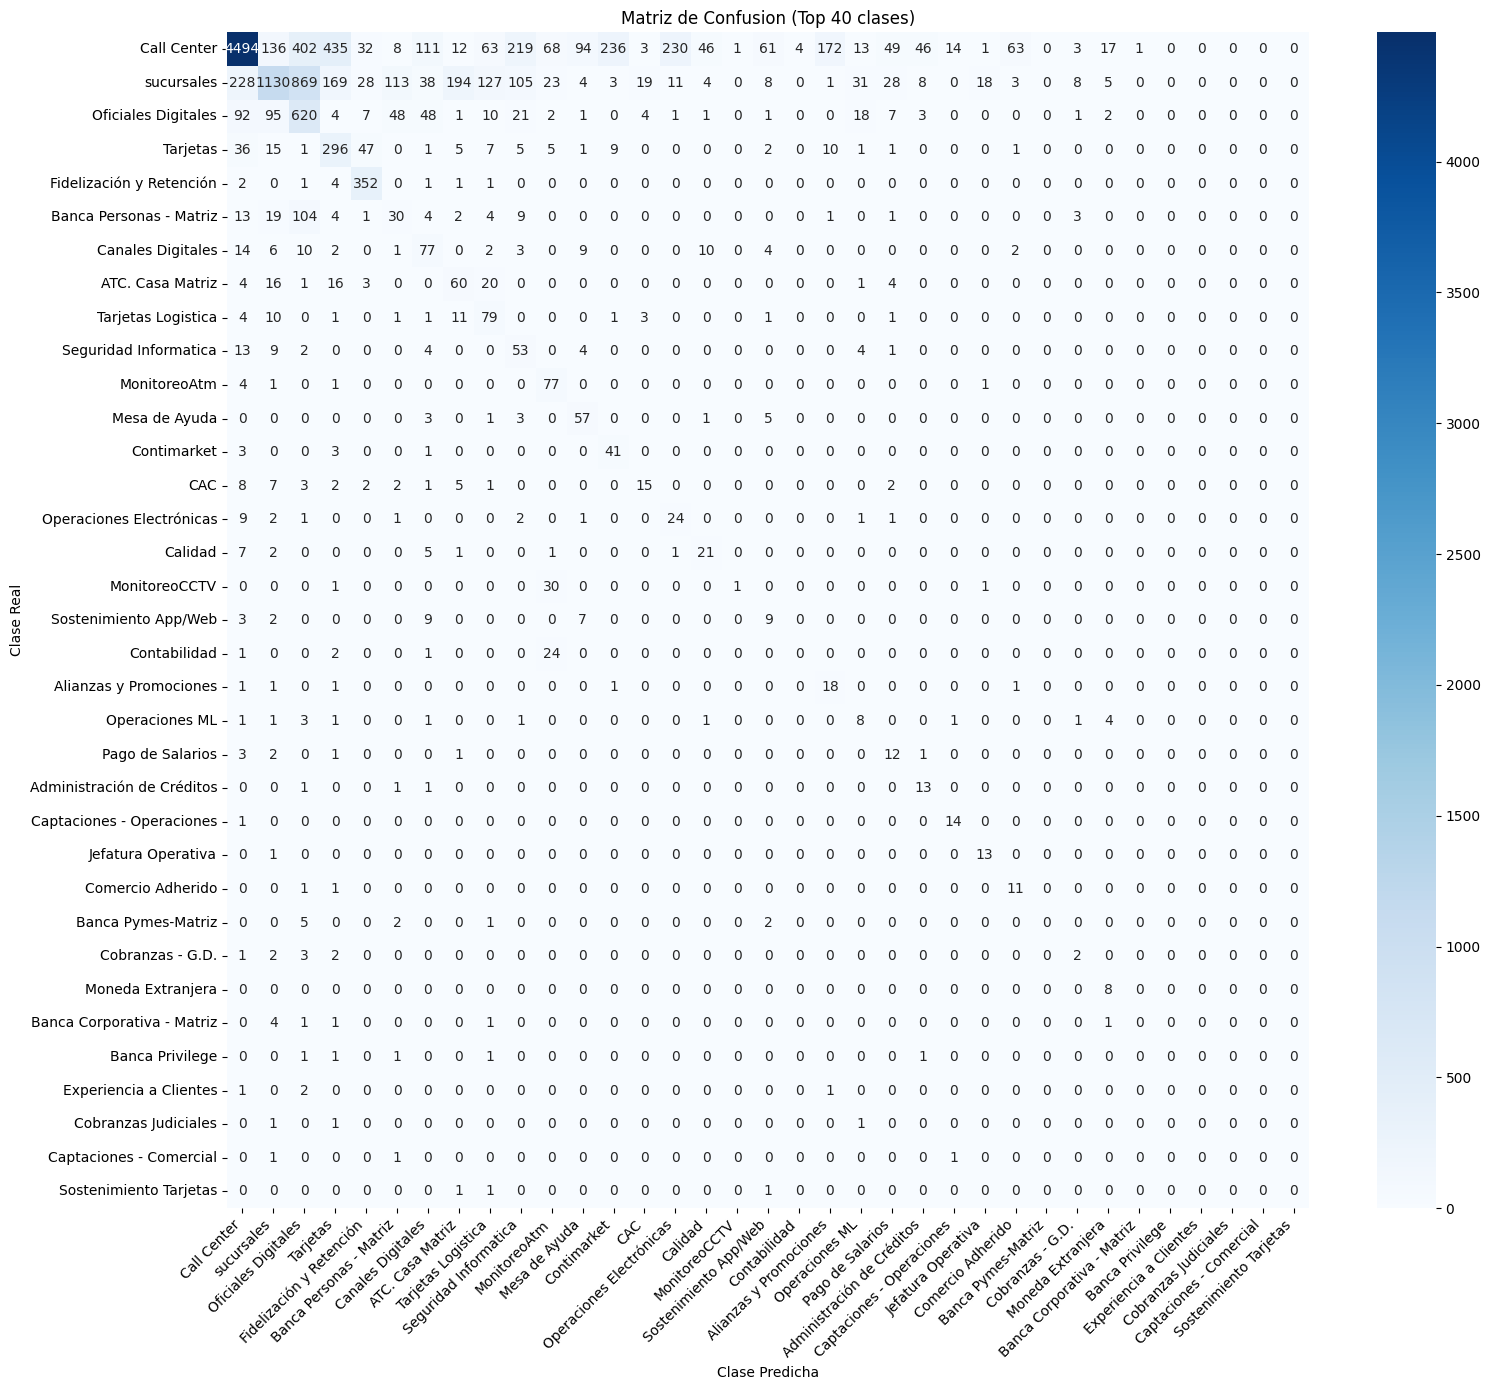


Interpretacion de la Matriz de Confusion:
- Diagonal (esquina sup-izq a inf-der): predicciones CORRECTAS
- Fuera de la diagonal: ERRORES
- Ejemplo: si la celda [Call Center, Sucursal] tiene 50,
  significa que 50 tickets de Call Center fueron clasificados como Sucursal


In [37]:
# === MATRIZ DE CONFUSION ===
# Muestra una tabla donde:
# - Filas = clase REAL
# - Columnas = clase PREDICHA
# - La diagonal = predicciones correctas
# - Fuera de la diagonal = errores (muestra que clases se confunden entre si)

# Limitamos a las 15 clases mas frecuentes para que el grafico sea legible
top_n = 40  # Cantidad de clases a mostrar

# Obtenemos las N clases mas frecuentes del test set
top_classes_idx = pd.Series(all_labels).value_counts().head(top_n).index.tolist()

# Filtramos solo las predicciones y etiquetas de esas clases
mask = np.isin(all_labels, top_classes_idx)  # Mascara booleana: True donde la etiqueta esta en top_n
filtered_labels = all_labels[mask]  # Etiquetas filtradas
filtered_preds = all_predictions[mask]  # Predicciones filtradas

# Calculamos la matriz de confusion
cm = confusion_matrix(filtered_labels, filtered_preds, labels=top_classes_idx)

# Obtenemos los nombres de las clases para los ejes
top_class_names = label_encoder.inverse_transform(top_classes_idx)

# Creamos el grafico
plt.figure(figsize=(16, 14))  # Figura grande para que sea legible

# Heatmap: colores mas intensos = mas ejemplos en esa celda
sns.heatmap(
    cm,  # La matriz de confusion
    annot=True,  # Muestra los numeros dentro de cada celda
    fmt='d',  # Formato entero (no decimal)
    cmap='Blues',  # Escala de colores azul
    xticklabels=top_class_names,  # Nombres en eje X (predicciones)
    yticklabels=top_class_names,  # Nombres en eje Y (reales)
)

# Etiquetas y titulo
plt.title(f'Matriz de Confusion (Top {top_n} clases)')  # Titulo
plt.xlabel('Clase Predicha')  # Eje X
plt.ylabel('Clase Real')  # Eje Y

# Rotamos las etiquetas para que se lean bien
plt.xticks(rotation=45, ha='right')  # Rotar 45 grados, alinear a la derecha
plt.yticks(rotation=0)  # Sin rotacion

# Ajustamos layout y mostramos
plt.tight_layout()
plt.show()

# Interpretacion
print('\nInterpretacion de la Matriz de Confusion:')
print('- Diagonal (esquina sup-izq a inf-der): predicciones CORRECTAS')
print('- Fuera de la diagonal: ERRORES')
print('- Ejemplo: si la celda [Call Center, Sucursal] tiene 50,')  
print('  significa que 50 tickets de Call Center fueron clasificados como Sucursal')

## 13. Prediccion con textos nuevos

Esta funcion permite clasificar cualquier texto nuevo (sin necesidad de reentrenar).

In [35]:
def predict(text, model, tokenizer, label_encoder, device, top_k=3):
    """Clasifica un texto y devuelve las top-k clases mas probables."""
    
    # Ponemos el modelo en modo evaluacion (desactiva dropout)
    model.eval()
    
    # Tokenizamos el texto de entrada
    encoding = tokenizer.encode_plus(
        text,  # El texto a clasificar
        add_special_tokens=True,  # Agrega [CLS] y [SEP]
        max_length=MAX_LENGTH,  # Longitud maxima
        padding='max_length',  # Rellena hasta max_length
        truncation=True,  # Trunca si es mas largo
        return_attention_mask=True,  # Devuelve mascara
        return_tensors='pt',  # Devuelve tensores PyTorch
    )
    
    # Movemos los tensores a GPU
    input_ids = encoding['input_ids'].to(device)  # [1, max_length]
    attention_mask = encoding['attention_mask'].to(device)  # [1, max_length]
    
    # Hacemos la prediccion sin calcular gradientes
    with torch.no_grad():
        logits = model(input_ids, attention_mask)  # [1, num_classes]
    
    # Convertimos logits a probabilidades con softmax
    probabilities = torch.softmax(logits, dim=1)  # [1, num_classes]
    
    # Obtenemos las top-k clases con mayor probabilidad
    # torch.topk devuelve (valores, indices) de los k mayores
    top_probs, top_indices = torch.topk(probabilities, k=top_k, dim=1)
    
    # Convertimos a numpy y sacamos de GPU
    top_probs = top_probs.cpu().numpy()[0]  # Probabilidades
    top_indices = top_indices.cpu().numpy()[0]  # Indices de clase
    
    # Convertimos indices a nombres de clase usando el LabelEncoder
    top_classes = label_encoder.inverse_transform(top_indices)
    
    # Mostramos los resultados
    print(f'Texto: "{text[:100]}..."\n')  # Mostramos los primeros 100 caracteres
    print(f'Top {top_k} predicciones:')
    
    # Iteramos por las top-k predicciones
    for i, (cls, prob) in enumerate(zip(top_classes, top_probs)):
        # Mostramos la clase y su probabilidad
        bar = '█' * int(prob * 30)  # Barra visual proporcional a la probabilidad
        print(f'  {i+1}. {cls}: {prob:.4f} ({prob*100:.1f}%) {bar}')
    
    # Devolvemos la clase mas probable y todas las probabilidades
    return top_classes[0], dict(zip(top_classes, top_probs))

In [36]:
# === EJEMPLO 1: Consulta sobre tarjeta de credito ===
texto_1 = 'El cliente llama para solicitar el bloqueo de su tarjeta de credito porque fue robada'

# Llamamos a la funcion predict
clase_1, probs_1 = predict(texto_1, model, tokenizer, label_encoder, device)

print('\n' + '=' * 60 + '\n')

# === EJEMPLO 2: Problema con app movil ===
texto_2 = 'No puedo ingresar a la aplicacion movil, me sale error de autenticacion'

clase_2, probs_2 = predict(texto_2, model, tokenizer, label_encoder, device)

print('\n' + '=' * 60 + '\n')

# === EJEMPLO 3: Consulta sobre cuenta ===
texto_3 = 'Quiero saber el saldo de mi cuenta de ahorro y los ultimos movimientos'

clase_3, probs_3 = predict(texto_3, model, tokenizer, label_encoder, device)

AttributeError: BertTokenizer has no attribute encode_plus

## 14. Como detener, usar y reanudar el entrenamiento

### Escenario: Entrenaste 5 epocas, queres probar el modelo, y despues seguir entrenando.

**Paso 1 - Detener:** Interrumpi el kernel durante el entrenamiento (boton Stop).

**Paso 2 - Usar el modelo:** Ejecuta las celdas de abajo para cargar y usar el modelo.

In [ ]:
# === CARGAR EL MODELO GUARDADO (sin necesidad de reentrenar) ===
# Esto es lo que ejecutas cuando queres USAR el modelo despues de cerrar todo

# Paso 1: Reconstruimos el modelo (misma arquitectura)
model = BERTClassifier(
    model_name=MODEL_NAME,  # Mismo modelo base
    num_classes=num_classes,  # Misma cantidad de clases
)

# Paso 2: Lo movemos a GPU
model = model.to(device)

# Paso 3: Cargamos los pesos del mejor modelo guardado
load_checkpoint(model, path=os.path.join(CHECKPOINT_DIR, 'best_model.pt'))

# Ahora podes usar predict() con cualquier texto!
print('\nModelo listo para usar!')

**Paso 3 - Reanudar entrenamiento:**  
Si despues de probar el modelo queres seguir entrenando mas epocas, ejecuta la celda de abajo.  
Carga el ultimo checkpoint (con estado del optimizador y scheduler) y continua desde donde quedo.

In [ ]:
# === REANUDAR ENTRENAMIENTO ===
# Ejecuta esto si queres seguir entrenando despues de haber parado

# Paso 1: Reconstruimos modelo, optimizador y scheduler
model = BERTClassifier(model_name=MODEL_NAME, num_classes=num_classes)  # Arquitectura
model = model.to(device)  # A la GPU

# Reconfiguramos el optimizador (mismo que antes)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),  # Solo parametros entrenables
    lr=LEARNING_RATE,  # Mismo learning rate
    weight_decay=0.01,  # Misma regularizacion
)

# Definimos cuantas epocas ADICIONALES queremos entrenar
EXTRA_EPOCHS = 5  # Cambia este numero segun lo que necesites

# Recalculamos el scheduler para las epocas restantes
extra_total_steps = len(train_loader) * EXTRA_EPOCHS  # Pasos adicionales
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(extra_total_steps * 0.1),  # 10% warmup
    num_training_steps=extra_total_steps,
)

# Paso 2: Cargamos el checkpoint (restaura pesos, optimizador y scheduler)
resume_epoch, resume_step = load_checkpoint(
    model, optimizer, scheduler,
    path=os.path.join(CHECKPOINT_DIR, 'last_checkpoint.pt'),
)

# Mostramos desde donde se reanuda
print(f'\nReanudando desde epoca {resume_epoch}')
print(f'Entrenando {EXTRA_EPOCHS} epocas adicionales...')
print('Vuelve a ejecutar la celda de entrenamiento (Seccion 10) con:')
print(f'  - start_epoch = {resume_epoch}')
print(f'  - NUM_EPOCHS = {resume_epoch + EXTRA_EPOCHS}')

## 15. Resumen y proximos pasos

### Lo que hicimos:
1. Cargamos tickets de CRM con `descripcion` y `areas_resolutora`
2. Usamos **BETO** (BERT en español) como extractor de features (transfer learning)
3. Congelamos BERT y solo entrenamos una capa clasificadora (~0.2% de parametros)
4. Evaluamos con multiples metricas (accuracy, precision, recall, F1, top-k)

### Para mejorar el modelo:
- **Descongelar las ultimas capas de BERT** (fine-tuning parcial): mejor rendimiento pero mas lento
- **Aumentar MAX_LENGTH** si muchos textos se truncan
- **Limpiar los datos**: eliminar firmas, saludos, formato repetitivo de los tickets
- **Class weighting**: usar pesos en CrossEntropyLoss para clases desbalanceadas
- **Data augmentation**: parafrasear textos para aumentar ejemplos de clases minoritarias

### Archivos generados:
- `checkpoints/best_model.pt`: mejor modelo (menor val_loss)
- `checkpoints/last_checkpoint.pt`: ultimo checkpoint (para reanudar)